# Fast Simulated Annealing (FSA)

## Quick introduction to FSA

* $T_0 \in \mathbb{R}$ initial temperature
* $ n_0 \in \mathbb{N} $ and $ \alpha \in \mathbb{R}$ — cooling strategy parameters
* $k$-th step:
  * Evaluate current temperature:
    * $ T = \frac{T_0}{1+(k/n_0)^\alpha} $ for $ \alpha > 0 $,
    * $ T = T_0 \cdot \exp(-(k/n_0)^{-\alpha}) $ otherwise.
  * **Mutate** the solution `x` -> `y`
  * $s = \frac{f_x-f_y}{T}$
  * replace `x` with `y` if $u < 1/2 + \arctan(s)/\pi$ where $u$ is random (uniform) number
  
Cauchy **mutation operator**:

* mutation perimeter (width) controlled by parameter $r \in \mathbb{R}$
* $ \mathbf{x}_\mathrm{new} = \mathbf{x} + r \cdot \tan{\left(\pi \left(\mathbf{r} - \dfrac{1}{2}\right)\right)} $ where $\mathbf{r}$ is random uniform vector


In [1]:
# Import path to source directory (bit of a hack in Jupyter)
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

# Ensure modules are reloaded on any change (very useful when developing code on the fly)
%load_ext autoreload
%autoreload 2

In [2]:
# Import external libraries
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## Initialize Recommender

In [3]:
from objfun_recommender import Recommender

recommender = Recommender()
num_states = int(np.prod(recommender.b - recommender.a + 1))
maxeval = int(num_states * 0.01)  # 1% of state space
NUM_RUNS = 10_000
print(f'num_states = {num_states:,}, maxeval = {maxeval}')

num_states = 10,000, maxeval = 100


## Recommender optimization using FSA

Please, inspect the new code first!

In [4]:
from heur_fsa import FastSimulatedAnnealing
from heur_aux import Correction, CauchyMutation

Let's evaluate performance of different temperatures...

In [5]:
def experiment_fsa(of, maxeval, num_runs, T0, n0, alpha, r):
    results = []
    for i in tqdm(range(num_runs), 'Testing T0={}, n0={}, alpha={}, r={}'.format(T0, n0, alpha, r)):
        mut = CauchyMutation(r=r, correction=Correction(of))
        result = FastSimulatedAnnealing(of, maxeval=maxeval, T0=T0, n0=n0, alpha=alpha, mutation=mut, seed=i).search()
        result['run'] = i
        result['heur'] = 'FSA_{}_{}_{}_{}'.format(T0, n0, alpha, r)
        result['T0'] = T0
        result['n0'] = n0
        result['alpha'] = alpha
        result['r'] = r
        results.append(result)

    return pd.DataFrame(results, columns=['heur', 'run', 'T0', 'n0', 'alpha', 'r', 'best_x', 'best_y', 'neval', 'success'])

In [6]:
table_fsa = pd.DataFrame()

for T0 in [1e-10, 1e-2, 1, np.inf]:
    res = experiment_fsa(of=recommender, maxeval=maxeval, num_runs=NUM_RUNS, T0=T0, n0=1, alpha=2, r=1)
    table_fsa = pd.concat([table_fsa, res], axis=0)

Testing T0=1e-10, n0=1, alpha=2, r=1:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing T0=0.01, n0=1, alpha=2, r=1:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing T0=1, n0=1, alpha=2, r=1:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing T0=inf, n0=1, alpha=2, r=1:   0%|          | 0/10000 [00:00<?, ?it/s]

In [7]:
stats_fsa = table_fsa.groupby(['heur', 'T0'])[['neval', 'success']].apply(
    lambda g: pd.Series({
        'rel': g['success'].mean(),
        'mne': g.loc[g['success'], 'neval'].mean(),
        'feo': g.loc[g['success'], 'neval'].mean() / g['success'].mean()
    })
).reset_index()
stats_fsa.sort_values(by=['T0'])

,heur,T0,rel,mne,feo
2,FSA_1e-10_1_2_1,1.000000e-10,0.4232,55.963611,132.239155
0,FSA_0.01_1_2_1,1.000000e-02,0.4232,55.963847,132.239714
1,FSA_1_1_2_1,1.000000e+00,0.4228,55.912725,132.243909
3,FSA_inf_1_2_1,inf,0.0059,40.000000,6779.661017


# Analysis

The T0 sweep shows that all finite temperatures perform nearly identically (REL ≈ 42%, FEO ≈ 132), while T0=∞ fails badly. This tells us the temperature is almost irrelevant here: the default cooling schedule (n0=1, α=2) drops T so fast that the Metropolis acceptance criterion almost never triggers — FSA is effectively doing greedy descent from the start.

**Can we improve by slowing down the cooling (increasing $n_0$)?**

In [8]:
heur = FastSimulatedAnnealing(recommender, maxeval=maxeval, T0=1, n0=1, alpha=2,
                              mutation=CauchyMutation(r=1, correction=Correction(recommender)))
result = heur.search()
print('neval = {}'.format(result['neval']))
print('best_x = {}'.format(result['best_x']))
print('best_y = {}'.format(result['best_y']))

neval = 100
best_x = [80 20]
best_y = 18.0


In [9]:
log_data = result['log_data'].copy()
log_data = log_data[['step', 'x', 'f_x', 'y', 'f_y', 'T', 'swap']]  # column re-ordering, for better readability
log_data.head(10)

,step,x,f_x,y,f_y,T,swap
0,0,"[2, 4]",1330.25,"[64, 7]",145.5,1.000000,True
1,1,"[64, 7]",145.50,"[64, 15]",102.3,0.500000,True
2,2,"[64, 15]",102.30,"[65, 15]",93.0,0.200000,True
3,3,"[65, 15]",93.00,"[66, 15]",84.3,0.100000,True
4,4,"[66, 15]",84.30,"[67, 13]",83.4,0.058824,True
5,5,"[67, 13]",83.40,"[66, 8]",120.0,0.038462,False
6,6,"[67, 13]",83.40,"[86, 15]",36.3,0.027027,True
7,7,"[86, 15]",36.30,"[84, 15]",30.3,0.020000,True
8,8,"[84, 15]",30.30,"[85, 16]",30.3,0.015385,False
9,9,"[84, 15]",30.30,"[82, 17]",21.9,0.012195,True


In [10]:
def plot_compare(step_data, ax1_col, ax1_label, ax2_col, ax2_label):
    fig, ax1 = plt.subplots()

    k = step_data.index.values
    T = step_data[ax1_col]
    ax1.plot(k, T, 'b-')
    ax1.set_xlabel('Step')
    ax1.set_ylabel(ax1_label, color='b')
    for tl in ax1.get_yticklabels():
        tl.set_color('b')

    ax2 = ax1.twinx()
    s2 = step_data[ax2_col]
    ax2.plot(k, s2, 'r.')
    ax2.set_ylabel(ax2_label, color='r')
    for tl in ax2.get_yticklabels():
        tl.set_color('r')

    plt.show()

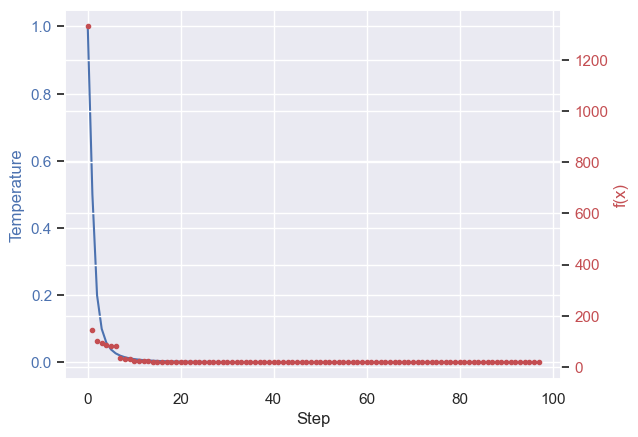

In [11]:
plot_compare(log_data, 'T', 'Temperature', 'f_x', 'f(x)')

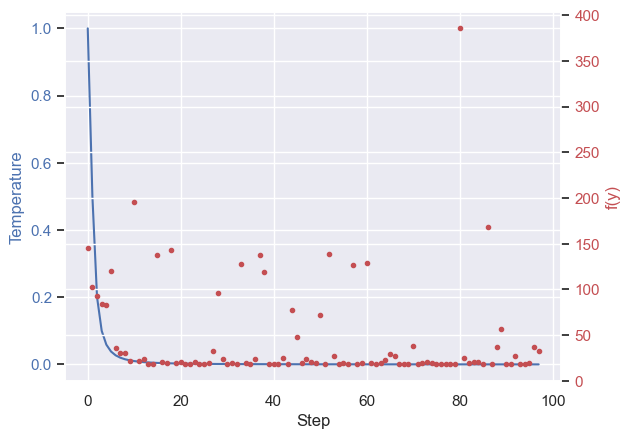

In [12]:
plot_compare(log_data, 'T', 'Temperature', 'f_y', 'f(y)')

**Cooling is too fast -> exploration phase is too short**.

Consequences:
* The algorithm can hardly escape local minima.
* It behaves almost like hill climbing after ~10 steps.

**Slower cooling?**

The single run with n0=1 got trapped at a local minimum [80, 20] (one of the two traps in the landscape). Let's try doubling $n_0$ to allow higher temperature for longer:

In [13]:
heur = FastSimulatedAnnealing(recommender, maxeval=maxeval, T0=1, n0=2, alpha=2,
                              mutation=CauchyMutation(r=1, correction=Correction(recommender)))
result = heur.search()
print('neval = {}'.format(result['neval']))
print('best_x = {}'.format(result['best_x']))
print('best_y = {}'.format(result['best_y']))

neval = 45
best_x = [37 68]
best_y = 0.0


In [14]:
log_data = result['log_data'].copy()
log_data = log_data[['step', 'x', 'f_x', 'y', 'f_y', 'T', 'swap']]  # column re-ordering, for better readability

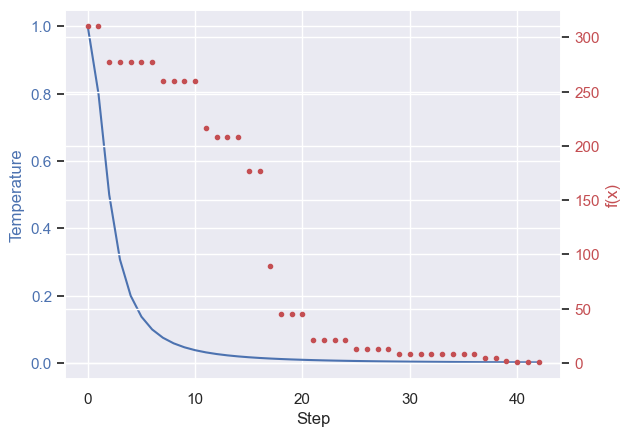

In [15]:
plot_compare(log_data, 'T', 'Temperature', 'f_x', 'f(x)')

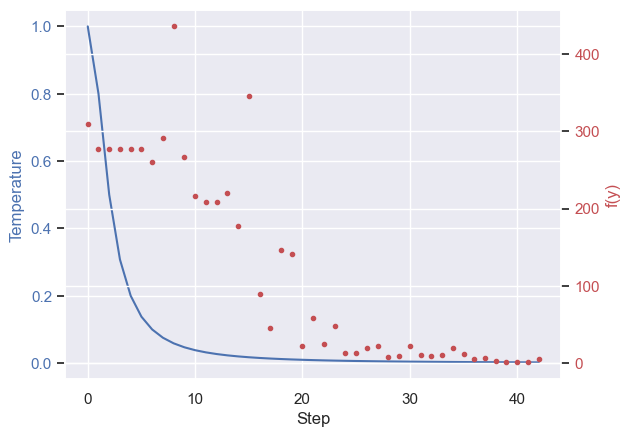

In [16]:
plot_compare(log_data, 'T', 'Temperature', 'f_y', 'f(y)')

This looks better, and the single run happened to find the global optimum — but a single run is not evidence of improvement. The mass experiment (below) will tell us whether slower cooling actually helps.

**Now, we need more thorough testing**:

In [17]:
for n0 in [2, 3, 5, 10]:
    res = experiment_fsa(of=recommender, maxeval=maxeval, num_runs=NUM_RUNS, T0=1, n0=n0, alpha=2, r=1)
    table_fsa = pd.concat([table_fsa, res], axis=0)

Testing T0=1, n0=2, alpha=2, r=1:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing T0=1, n0=3, alpha=2, r=1:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing T0=1, n0=5, alpha=2, r=1:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing T0=1, n0=10, alpha=2, r=1:   0%|          | 0/10000 [00:00<?, ?it/s]

In [18]:
stats_fsa = table_fsa.groupby(['heur', 'T0', 'n0'])[['neval', 'success']].apply(
    lambda g: pd.Series({
        'rel': g['success'].mean(),
        'mne': g.loc[g['success'], 'neval'].mean(),
        'feo': g.loc[g['success'], 'neval'].mean() / g['success'].mean()
    })
).reset_index()
stats_fsa.sort_values(by=['T0', 'n0'])

,heur,T0,n0,rel,mne,feo
6,FSA_1e-10_1_2_1,1.000000e-10,1,0.4232,55.963611,132.239155
0,FSA_0.01_1_2_1,1.000000e-02,1,0.4232,55.963847,132.239714
2,FSA_1_1_2_1,1.000000e+00,1,0.4228,55.912725,132.243909
3,FSA_1_2_2_1,1.000000e+00,2,0.4232,56.049622,132.442396
4,FSA_1_3_2_1,1.000000e+00,3,0.4226,56.201609,132.990083
5,FSA_1_5_2_1,1.000000e+00,5,0.4225,56.697041,134.194181
1,FSA_1_10_2_1,1.000000e+00,10,0.4169,57.317342,137.484630
7,FSA_inf_1_2_1,inf,1,0.0059,40.000000,6779.661017


The $n_0$ sweep suggests $n_0$ has no meaningful effect in the range 1–5 ($FEO$ stays flat at ~132–134). The cooling speed is not the bottleneck.

### Is the mutation $r$ adequate?

Another key parameter is the mutation width $r$. Before testing a range, let's inspect the actual jump lengths from the last single run:

In [19]:
log_data['jump_length'] = log_data.apply(lambda r: np.linalg.norm(r['x'] - r['y']), axis=1)
log_data.head(10)

,step,x,f_x,y,f_y,T,swap,jump_length
0,0,"[17, 39]",310.25,"[17, 39]",310.25,1.000000,True,0.000000
1,1,"[17, 39]",310.25,"[19, 40]",277.00,0.800000,True,2.236068
2,2,"[19, 40]",277.00,"[19, 40]",277.00,0.500000,False,0.000000
3,3,"[19, 40]",277.00,"[19, 40]",277.00,0.307692,False,0.000000
4,4,"[19, 40]",277.00,"[19, 40]",277.00,0.200000,False,0.000000
5,5,"[19, 40]",277.00,"[19, 40]",277.00,0.137931,True,0.000000
6,6,"[19, 40]",277.00,"[21, 40]",260.00,0.100000,True,2.000000
7,7,"[21, 40]",260.00,"[19, 39]",291.25,0.075472,False,2.236068
8,8,"[21, 40]",260.00,"[6, 40]",436.25,0.058824,False,15.000000
9,9,"[21, 40]",260.00,"[52, 39]",266.50,0.047059,False,31.016125


In [20]:
log_data['jump_length'].describe()

count    43.000000
mean      5.313234
std       7.502524
min       0.000000
25%       1.000000
50%       2.236068
75%       5.061553
max      31.016125
Name: jump_length, dtype: float64

In [21]:
for r in [0.5, 1, 2, 5, 10]:
    res = experiment_fsa(of=recommender, maxeval=maxeval, num_runs=NUM_RUNS, T0=1, n0=5, alpha=2, r=r)
    table_fsa = pd.concat([table_fsa, res], axis=0)

Testing T0=1, n0=5, alpha=2, r=0.5:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing T0=1, n0=5, alpha=2, r=1:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing T0=1, n0=5, alpha=2, r=2:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing T0=1, n0=5, alpha=2, r=5:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing T0=1, n0=5, alpha=2, r=10:   0%|          | 0/10000 [00:00<?, ?it/s]

In [22]:
stats_fsa = table_fsa.groupby(['heur', 'T0', 'n0', 'r'])[['neval', 'success']].apply(
    lambda g: pd.Series({
        'rel': g['success'].mean(),
        'mne': g.loc[g['success'], 'neval'].mean(),
        'feo': g.loc[g['success'], 'neval'].mean() / g['success'].mean()
    })
).reset_index()
stats_fsa.sort_values(by=['T0', 'n0', 'r'])

,heur,T0,n0,r,rel,mne,feo
10,FSA_1e-10_1_2_1,1.000000e-10,1,1.0,0.4232,55.963611,132.239155
0,FSA_0.01_1_2_1,1.000000e-02,1,1.0,0.4232,55.963847,132.239714
2,FSA_1_1_2_1,1.000000e+00,1,1.0,0.4228,55.912725,132.243909
3,FSA_1_2_2_1,1.000000e+00,2,1.0,0.4232,56.049622,132.442396
4,FSA_1_3_2_1,1.000000e+00,3,1.0,0.4226,56.201609,132.990083
5,FSA_1_5_2_0.5,1.000000e+00,5,0.5,0.3698,62.432937,168.828926
6,FSA_1_5_2_1,1.000000e+00,5,1.0,0.4225,56.697041,134.194181
8,FSA_1_5_2_2,1.000000e+00,5,2.0,0.3354,56.742993,169.180064
9,FSA_1_5_2_5,1.000000e+00,5,5.0,0.1129,58.031887,514.011396
7,FSA_1_5_2_10,1.000000e+00,5,10.0,0.0403,59.774194,1483.230609


Notice that several rows have `jump_length` = 0: Cauchy mutation with $r=1$ on an **integer** domain can produce sub-0.5 increments that round to zero — a wasted evaluation. The 25th percentile of jump length is 1.0, meaning at least a quarter of mutations produce a step of 1 unit or less, a fraction of which are outright zero-moves. This is a subtle but real inefficiency for integer-valued search spaces.

The $r$ sweep confirms $r=1$ is the sweet spot: smaller $r$ produces too many zero-moves, larger $r$ overshoots the basin entirely. The best performing configuration:

In [23]:
stats_fsa.sort_values(by=['feo']).head(1)

,heur,T0,n0,r,rel,mne,feo
10,FSA_1e-10_1_2_1,1.000000e-10,1,1.0,0.4232,55.963611,132.239155


## Conclusion

* **$T_0$ is largely irrelevant** for this problem: all finite temperatures (1e-10 to 1) produce virtually identical results ($REL$ ≈ 42%, $FEO$ ≈ 132). The default cooling schedule is aggressive enough that the Metropolis criterion almost never accepts worsening moves regardless of $T_0$. $T_0 = \infty$ is the only configuration that degrades performance significantly ($REL$ drops to 0.6%).

* **$n_0$ is equally insensitive** in the tested range (1–5). Slower cooling does not help because the temperature is already low enough to act greedy from very early on.

* **$r$ is the only parameter that matters.** $r=1$ is the clear optimum for this [0, 99]² integer domain — smaller values cause excessive zero-length mutations (Cauchy increments below 0.5 are rounded away), and larger values cause jumps that overshoot the basin of attraction.

* **FSA outperforms Shoot & Go** from the previous notebook: the best FSA configuration achieves $FEO$ ≈ 132, compared to SG-RD-∞ ($FEO$ ≈ 163) and SG-SD-∞ ($FEO$ ≈ 970). The improvement comes from FSA's ability to occasionally accept worse solutions early in the search, allowing it to escape shallow traps before the temperature drops, combined with a more expressive Cauchy mutation.

* **Open issue:** zero-length mutations in integer domains waste evaluations. A mutation operator that guarantees at least a 1-step move would likely improve performance further — see Assignment 1.

## But the key takeaway here should be...

...to use "telemetry data" analysis to connect high-level testing results with the inner workings of the actual optimization algorithm.

## Assignment

1. Could you further improve performance of FSA on this Recommender instance? Try other mutation correction strategies (`MirrorCorrection`, `ExtensionCorrection`) and compare.
2. We have performed analyses of the `log_data` contents on a single run. Try to aggregate and make use of these statistics across multiple experimental runs.
3. When FSA search is successful, the last objective function call is missing in the `log_data` output. Could you improve this behaviour?